# Recipe Clustering with KMeans

Coursework from **Applied Unsupervised Learning in Python** (University of Michigan, More Applied Data Science with Python specialization).

Can an algorithm with no labels rediscover the sweet versus savory split that every cook knows? We turn ingredient text into TFIDF vectors and let KMeans decide how many groups the data supports.

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("dark_background")
BG = "#0F172A"; AMBER = "#F59E0B"; TEAL = "#14B8A6"; INK = "#E2E8F0"; RED = "#EF4444"
plt.rcParams.update({"figure.facecolor": BG, "axes.facecolor": BG,
                     "savefig.facecolor": BG, "text.color": INK,
                     "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK})

recipes = pd.read_csv("../data/RAW_recipes_processed.csv")
ingredients = recipes["ingredients"].dropna()
print("recipes loaded:", recipes.shape[0])

from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize(texts, ngram_range=(1, 2), max_features=1000):
    vec = TfidfVectorizer(max_df=0.5, max_features=max_features, min_df=2,
                          stop_words="english", ngram_range=ngram_range, use_idf=True)
    return vec.fit_transform(texts), vec
X, vectorizer = vectorize(ingredients.values[:10000])
print("TFIDF matrix:", X.shape)

recipes loaded: 10000
TFIDF matrix: (10000, 1000)


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, init="k-means++", max_iter=100, n_init=1, random_state=42)
    lab = km.fit_predict(X)
    scores[k] = calinski_harabasz_score(X.toarray(), lab)
    print(f"K={k}  Calinski Harabasz={scores[k]:.2f}")
best_k = max(scores, key=scores.get)
print(f"Best K={best_k}  score={scores[best_k]:.2f}")

K=2  Calinski Harabasz=245.46
K=3  Calinski Harabasz=191.69
K=4  Calinski Harabasz=160.71
K=5  Calinski Harabasz=142.00
K=6  Calinski Harabasz=123.76
K=7  Calinski Harabasz=112.06
K=8  Calinski Harabasz=105.88
K=9  Calinski Harabasz=101.40
Best K=2  score=245.46


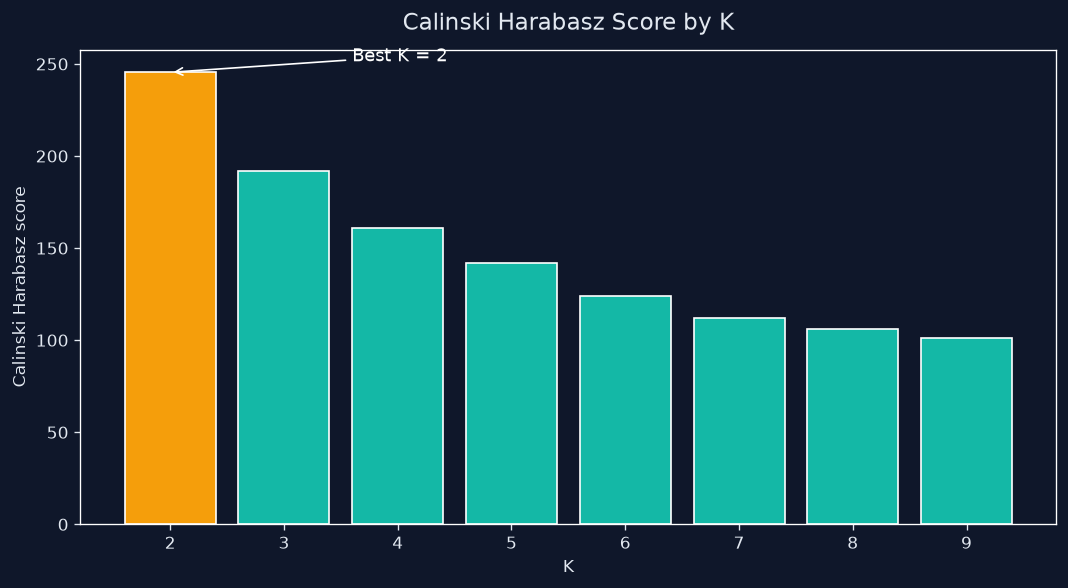

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ks = list(scores.keys())
vals = [scores[k] for k in ks]
ax.bar(ks, vals, color=[AMBER if k == best_k else TEAL for k in ks], edgecolor="white")
ax.set_title("Calinski Harabasz Score by K", fontsize=14, pad=12)
ax.set_xlabel("K")
ax.set_ylabel("Calinski Harabasz score")
ax.set_xticks(ks)
ax.annotate(f"Best K = {best_k}", xy=(best_k, scores[best_k]),
            xytext=(best_k + 1.6, scores[best_k] + 6),
            arrowprops=dict(arrowstyle="->", color="white"), color="white", fontsize=11)
fig.tight_layout()
fig.savefig("../charts/chart_ch_scores.png", dpi=120)

In [4]:
kmeans = KMeans(n_clusters=best_k, init="k-means++", max_iter=100, n_init=1, random_state=42)
cluster = kmeans.fit_predict(X)
for c in range(best_k):
    print(f"Cluster {c}: {(cluster == c).sum()} recipes")

Cluster 0: 4448 recipes
Cluster 1: 5552 recipes


In [5]:
terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_
for c in range(best_k):
    order = np.argsort(centroids[c])[::-1][:10]
    print(f"Cluster {c} top terms:", ", ".join(terms[order]))

Cluster 0 top terms: sugar, flour, baking, butter, cinnamon, vanilla, milk, eggs, apples, water
Cluster 1 top terms: pepper, cheese, garlic, fresh, oil, salt, onion, sauce, ground, chicken


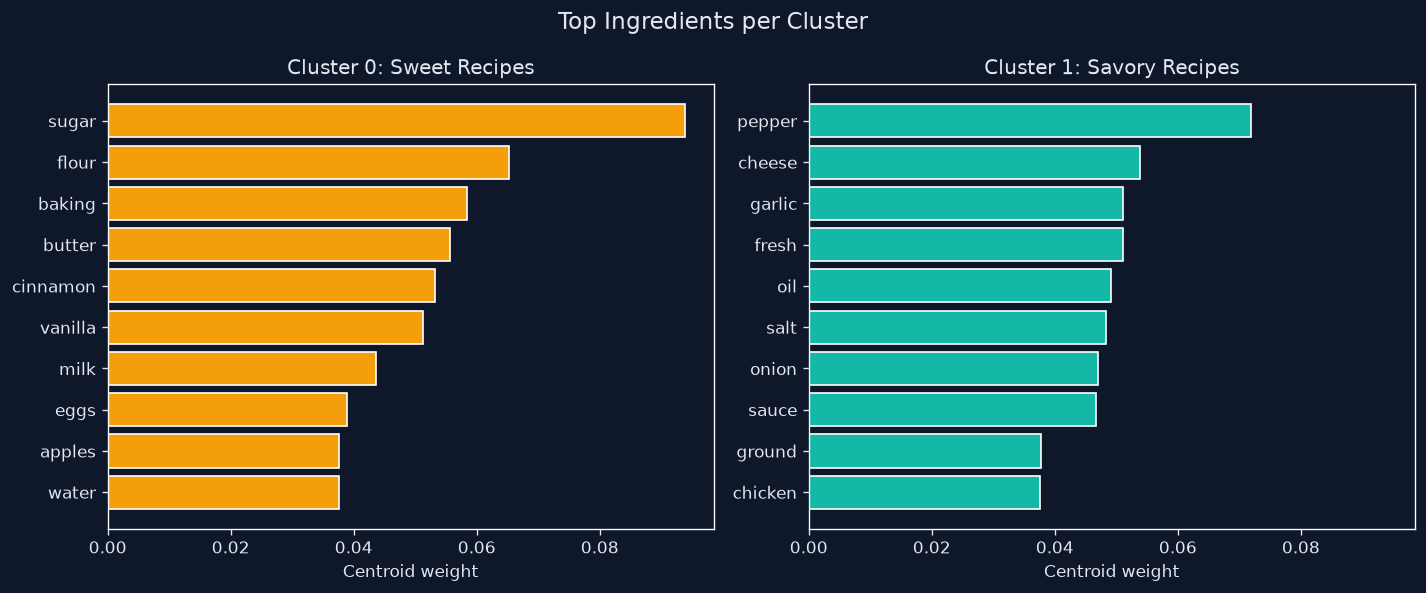

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
titles = ["Cluster 0: Sweet Recipes", "Cluster 1: Savory Recipes"]
colors = [AMBER, TEAL]
for c in range(best_k):
    ax = axes[c]
    order = np.argsort(centroids[c])[::-1][:10]
    ax.barh(terms[order][::-1], centroids[c][order][::-1], color=colors[c], edgecolor="white")
    ax.set_title(titles[c], fontsize=12)
    ax.set_xlabel("Centroid weight")
fig.suptitle("Top Ingredients per Cluster", fontsize=14)
fig.tight_layout()
fig.savefig("../charts/chart_top_terms.png", dpi=120)

PCA explained variance ratio: [0.0317 0.0153]


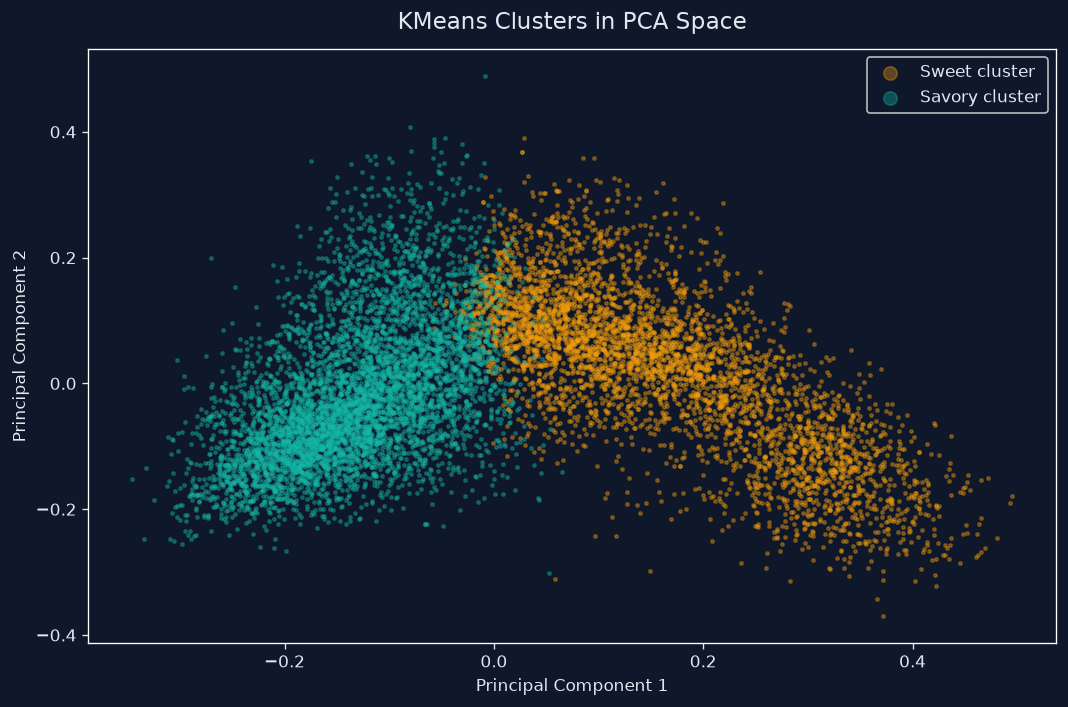

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
print("PCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(coords[cluster == 0, 0], coords[cluster == 0, 1], s=4, alpha=0.35,
            color=AMBER, label="Sweet cluster")
ax.scatter(coords[cluster == 1, 0], coords[cluster == 1, 1], s=4, alpha=0.35,
            color=TEAL, label="Savory cluster")
ax.set_title("KMeans Clusters in PCA Space", fontsize=14, pad=12)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(markerscale=4, framealpha=0.9)
fig.tight_layout()
fig.savefig("../charts/chart_pca_kmeans.png", dpi=120)

## Findings

* K = 2 wins clearly with a Calinski Harabasz score of 245.46. Scores fall steadily as K grows, so two groups is the natural split.
* Cluster 0 is the sweet side: sugar, flour, baking, butter, cinnamon, vanilla, milk, eggs, apples, water.
* Cluster 1 is the savory side: pepper, cheese, garlic, fresh, oil, salt, onion, sauce, ground, chicken.
* No labels were given. The algorithm rediscovered the dessert versus dinner divide on its own.